In [14]:
from selenium import webdriver
from bs4 import BeautifulSoup
from selenium.webdriver.common.by import By
import time 

In [15]:
# Constantes du projet
NB_ANNONCES_MAX = 50
EXPORT_PATH = "./exports/"

In [93]:
url = "https://www.pretapartir.fr/recherche#!?th=SJ&sort=promo_desc&depart=A_BOD&dureeNuit=7-99"
options = webdriver.ChromeOptions()
options.add_argument('headless')

browser = webdriver.Chrome(options=options)
browser.get(url)

time.sleep(2)

# -------------------------------
#  nombre de résultats de la recherche
soup = BeautifulSoup(browser.page_source, 'html.parser')
nb_elt = int(soup.find('h1').find('strong', class_='ng-binding').get_text(strip=True))


# nombre de fois à cliquer pour charger le reste d'éléments de la recherche
nb_click = NB_ANNONCES_MAX / 10 - 1 if nb_elt >= NB_ANNONCES_MAX else nb_elt // 10

# --------------------------------
for i in range(0, int(nb_click)):
    button_next_10 = browser.find_element(By.CSS_SELECTOR,"a[ng-click='vm.loadMorePackage()']")
    # button_next_10.click()
    browser.execute_script("arguments[0].click()", button_next_10)
    time.sleep(2)

soup = BeautifulSoup(browser.page_source, 'html.parser')

browser.quit()



In [94]:
# --------------------------------

# récupérer les items
items = soup.find_all('div', {"class":"blocProduct"})
print(len(items))

60


In [95]:
# fonction de nettoyage des données collectées
def clean_elt(str):
    return str.replace("\n", "").replace("\t", "")

In [100]:
item = items[0]
pays = clean_elt(item.find('p',{"class":"blocProduct-place"}).get_text(strip=True)).replace(" ", "").replace("-", ", ")
hotel = clean_elt(item.find('p',{"class":"blocProduct-title"}).get_text(strip=True))
details = soup.find('div', {"class":"blocProduct-detail"}).find_all()
duree = details[0].get_text(strip=True)
depart = details[1].get_text()

detailsPrice = soup.find('div', {"class":"blocProduct-price"}).find_all()
price = int(detailsPrice[1].get_text(strip=True).split()[0].replace("/","").replace("€",""))



In [104]:
# stocker sous forme de liste {}
voyages = []
for item in items:
    pays = clean_elt(item.find('p',{"class":"blocProduct-place"}).get_text(strip=True)).replace(" ", "").replace("-", ", ")
    hotel = clean_elt(item.find('p',{"class":"blocProduct-title"}).get_text(strip=True))
    details = soup.find('div', {"class":"blocProduct-detail"}).find_all()
    duree = details[0].get_text(strip=True)
    depart = details[1].get_text()
    detailsPrice = soup.find('div', {"class":"blocProduct-price"}).find_all()
    price = int(detailsPrice[1].get_text(strip=True).split()[0].replace("/","").replace("€",""))

    voyage = {
        "pays": pays,
        "hôtel": hotel,
        "départ": depart,
        "durée": duree,
        "prix (par personne)": price
    }

    voyages.append(voyage)

# voyages

In [105]:
# exporter sous excel
import pandas as pd

df = pd.DataFrame(voyages)

df.to_excel(EXPORT_PATH + "datatrip.xlsx", index=False)

# df

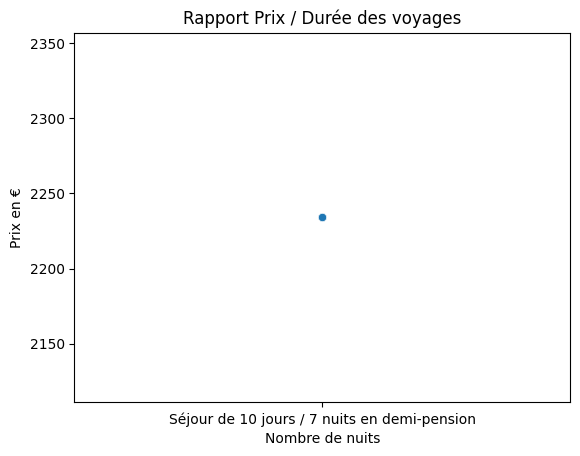

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seaborn crée le graphique stylé
sns.scatterplot(data=df, x="durée", y="prix (par personne)")

# 2. Matplotlib peaufine les détails
plt.title("Rapport Prix / Durée des voyages")
plt.xlabel("Nombre de nuits")
plt.ylabel("Prix en €")

plt.show()